# HW1 - 2D Flow Matching

Question: how can a model learn to move noise into data?


> CPU smoke run: this notebook is designed to execute quickly on CPU to verify mechanics, tensor shapes, plotting, and sampler logic. Generated samples may look like noise because the default training loop is intentionally tiny. Treat noisy samples as undertraining, not as evidence that the method is wrong. For meaningful visual quality, run longer on a GPU by increasing training steps, batch size, diffusion steps, and model width.


Sources:

- TorchCFM 2D tutorials: https://github.com/atong01/conditional-flow-matching/tree/main/examples/2D_tutorials
- Meta flow_matching examples: https://github.com/facebookresearch/flow_matching/tree/main/examples
- Flow Matching: https://arxiv.org/abs/2210.02747

This notebook uses a tiny MLP so the core idea is visible without framework abstractions.


In [1]:
import math
import random
from pathlib import Path
from io import BytesIO

import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
from IPython.display import Image, display

torch.manual_seed(7)
random.seed(7)
torch.set_num_threads(1)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


def show_plot():
    fig = plt.gcf()
    buf = BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", dpi=120)
    display(Image(data=buf.getvalue()))
    plt.close(fig)


device: cpu


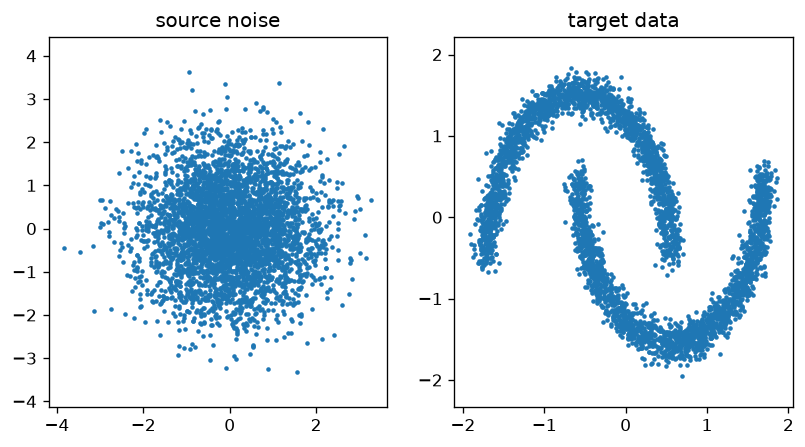

In [2]:
def sample_moons(n, noise=0.06):
    n1 = n // 2
    n2 = n - n1
    t1 = torch.rand(n1) * math.pi
    t2 = torch.rand(n2) * math.pi
    x1 = torch.stack([torch.cos(t1), torch.sin(t1)], dim=1)
    x2 = torch.stack([1 - torch.cos(t2), 0.5 - torch.sin(t2)], dim=1)
    x = torch.cat([x1, x2], dim=0)
    x = x + noise * torch.randn_like(x)
    return (x - x.mean(0)) / x.std(0)


data = sample_moons(4096)
noise = torch.randn_like(data)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, pts, title in [(axes[0], noise, "source noise"), (axes[1], data, "target data")]:
    ax.scatter(pts[:, 0], pts[:, 1], s=3)
    ax.set_title(title)
    ax.axis("equal")
show_plot()


## Training Target

For the simplest straight path:

```text
x_t = (1 - t) * x0 + t * x1
target velocity = x1 - x0
```

The network sees `(x_t, t)` and predicts velocity. Sampling starts from noise and repeatedly moves in the predicted direction.


In [3]:
class TimeMLP(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, 2),
        )

    def forward(self, x, t):
        if t.ndim == 1:
            t = t[:, None]
        return self.net(torch.cat([x, t], dim=1))


model = TimeMLP().to(device)
opt = torch.optim.AdamW(model.parameters(), lr=2e-3)
print(sum(p.numel() for p in model.parameters()), "parameters")


33794 parameters


0 1.7983
20 2.0575
40 1.9993
60 1.4351


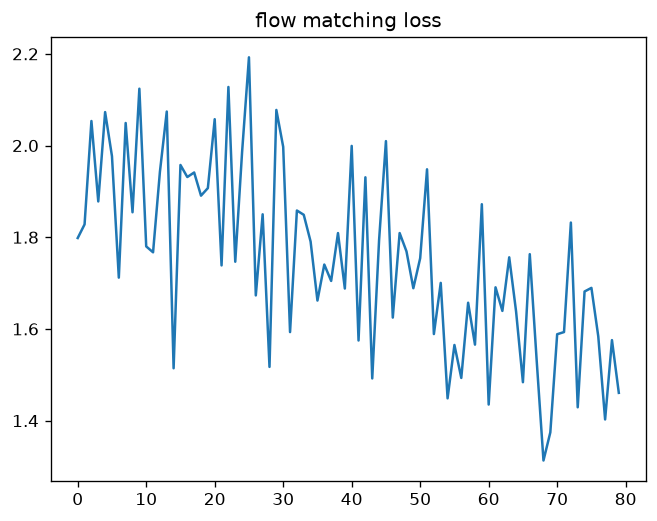

In [4]:
losses = []
for step in range(80):
    x1 = sample_moons(128).to(device)
    x0 = torch.randn_like(x1)
    t = torch.rand(x1.shape[0], 1, device=device)
    xt = (1 - t) * x0 + t * x1
    target_v = x1 - x0
    pred_v = model(xt, t.squeeze(1))
    loss = F.mse_loss(pred_v, target_v)
    opt.zero_grad()
    loss.backward()
    opt.step()
    losses.append(loss.item())
    if step % 20 == 0:
        print(step, round(loss.item(), 4))

plt.plot(losses)
plt.title("flow matching loss")
show_plot()


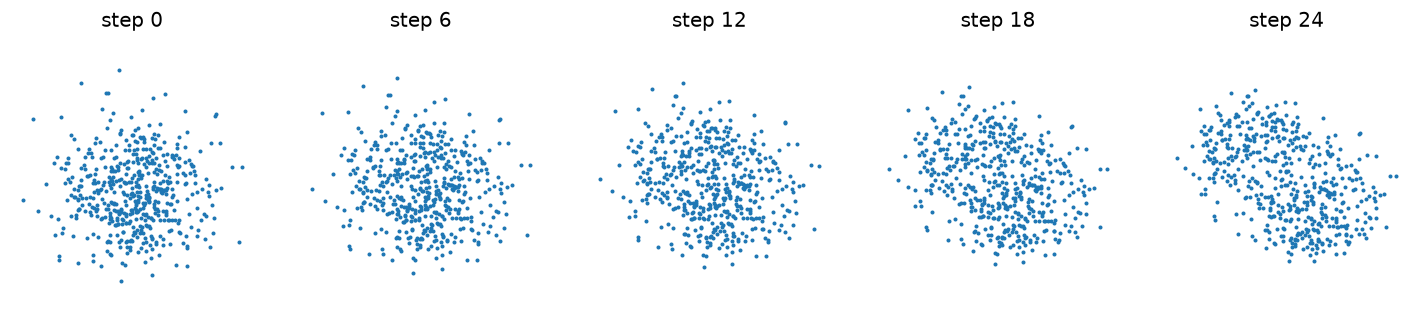

In [5]:
@torch.no_grad()
def sample_flow(n=512, steps=24, keep_trajectory=True):
    x = torch.randn(n, 2, device=device)
    trajectory = [(0, x.cpu())]
    dt = 1.0 / steps
    for i in range(steps):
        t = torch.full((n,), i / steps, device=device)
        x = x + dt * model(x, t)
        if keep_trajectory and i in [5, 11, 17, 23]:
            trajectory.append((i + 1, x.cpu()))
    return x.cpu(), trajectory


samples, trajectory = sample_flow()
fig, axes = plt.subplots(1, len(trajectory), figsize=(3 * len(trajectory), 3))
for ax, (step, pts) in zip(axes, trajectory):
    ax.scatter(pts[:, 0], pts[:, 1], s=2)
    ax.set_title(f"step {step}")
    ax.axis("equal")
    ax.axis("off")
show_plot()


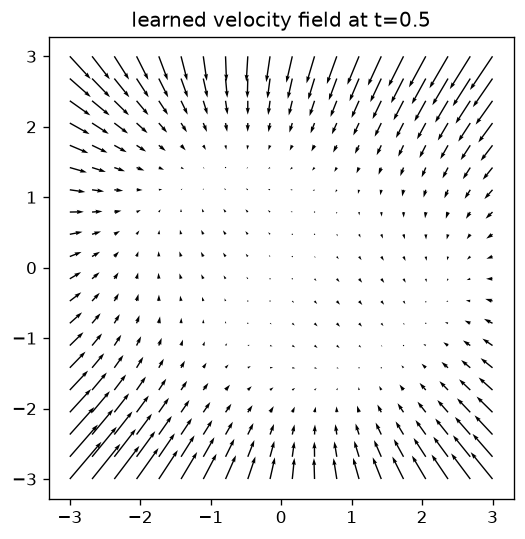

In [6]:
@torch.no_grad()
def plot_velocity_field(t_value=0.5):
    grid_x, grid_y = torch.meshgrid(torch.linspace(-3, 3, 20), torch.linspace(-3, 3, 20), indexing="xy")
    pts = torch.stack([grid_x.reshape(-1), grid_y.reshape(-1)], dim=1).to(device)
    t = torch.full((pts.shape[0],), t_value, device=device)
    v = model(pts, t).cpu()
    plt.figure(figsize=(5, 5))
    plt.quiver(pts.cpu()[:, 0], pts.cpu()[:, 1], v[:, 0], v[:, 1], angles="xy")
    plt.title(f"learned velocity field at t={t_value}")
    plt.axis("equal")
    show_plot()


plot_velocity_field(0.5)


## What To Say In An Interview

- Flow matching trains a vector field, not a denoiser.
- Sampling is an integration problem: start from source noise and follow the learned velocity.
- The Qwen connection is conceptual: modern systems may use flow-style objectives or diffusion-style objectives, but in both cases the model repeatedly predicts an update in latent/token space.
